# 02 · Synthetic worms: does the pipeline recover a known closed level?

The proposal's main scientific risk is that the data cannot discriminate between levels (§6). Its mitigation is to simulate worms **whose true closed level is known**, then confirm that the E1 pipeline recovers it before touching real data. This notebook implements that.

**Design.** A synthetic worm uses the real wiring, the real coverage (which pairs were measured, and how many trials), noise calibrated to the atlas, and a peptide contribution calibrated to the unc-31 estimate from Notebook 03. Its responses are generated by one rung of the ladder with randomly drawn parameters. We then run the *identical* cross-validated ladder and registered decision rule as Notebook 04 and ask:

1. **Recovery:** is L* equal to the true rung? (Ideal: a diagonal recovery matrix.)
2. **Power:** how strong must the peptide channel be, and how many trials are needed, for L3 to be distinguished from L2?
3. **Protocol:** how much harder is generalizing to wholly unseen stimulated neurons than to unseen (responder, stimulus) pairs?

**Lessons already learned while building this (see `closurebench` docstrings):**

* Loss normalization matters: the data loss is a relative error.
* Rungs L2–L4 are warm-started from the rung below, so depth cannot hurt the training fit. But warm starts alone **biased the rule toward deeper rungs**: they inherit their parent's training. On a 40-neuron test worm:

| fitting scheme | truth L1 → L* | truth L3 → L* |
|---|---|---|
| chain only | L3 | L4 |
| + equal optimization budget | L2 | — |
| + 3 restarts of L1 (current default) | **L1** | **L3** (marginal) |

  Without these controls, the ladder would favour the organismic verdict for reasons unrelated to mechanism.

* *Marginal* L3 recovery: held-out FEVE was L1 0.73, L2 0.71, L3 0.71, L4 0.71. The rule reached L3 because the CIs of L1 and L2 still allowed a >5% gain from deeper rungs, **not** because L3 measurably beat them. At this peptide strength and trial count, the pipeline does not wrongly reject the peptide rung, but it cannot positively detect it either. §3 quantifies this power.
* Bilateral homologs share parameters.
* With whole stimulated neurons held out, all rungs predicted *worse than zero*, because stimulus efficacy (opsin expression, the neuron's own excitability) is not identifiable for an unseen stimulus. The primary protocol therefore holds out (responder, stimulus) pairs and gives each stimulus an efficacy parameter. Whole-stimulus holdout is kept as a stricter secondary test.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, time, numpy as np, matplotlib.pyplot as plt, jax
from closurebench import data as D, ladder as lad, metrics as M
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
# ---- configuration by MODE (set in the setup cell; override with env CLOSUREBENCH_MODE) ----
#   smoke : random 16-neuron wiring, a few minutes; checks the code path only
#   laptop: 60-neuron real-wiring sub-network; ~2-4 h on an M1 CPU (see runtime estimate below)
#   full  : 120-neuron sub-network, 3 seeds, full power grid; GPU or multi-day CPU
CONF = {
    "smoke":  dict(N_NEURONS=16,  REAL_WIRING=False, TRUTHS=["L1", "L3"], SEEDS=[1], K=2, STEPS=15,  N_BOOT=100,
                   PEP_GRID=[0.5], TRIAL_GRID=[1]),
    "laptop": dict(N_NEURONS=60,  REAL_WIRING=True,  TRUTHS=["L1", "L2", "L3", "L4"], SEEDS=[1], K=3, STEPS=250,
                   N_BOOT=1000, PEP_GRID=[0.5, 1.0], TRIAL_GRID=[1, 4]),
    "full":   dict(N_NEURONS=120, REAL_WIRING=True,  TRUTHS=["L1", "L2", "L3", "L4"], SEEDS=[1, 2, 3], K=5, STEPS=500,
                   N_BOOT=2000, PEP_GRID=[0.25, 0.5, 1.0], TRIAL_GRID=[1, 2, 4]),
}[MODE]
globals().update(CONF)       # STEPS is per chain stage; with equal budgets each rung gets 4 x STEPS in total
PEPTIDE_SCALE = 0.5          # calibrated to Notebook 03 §4 (peptide SD ~ 0.4-0.6 x wired SD)
LEVELS = ["L0", "L1", "L2", "L3", "L4", "B"]

if REAL_WIRING:
    ds_path = os.path.join(RESULTS, "atlas_dataset.npz")
    real = D.Dataset.load(ds_path) if os.path.exists(ds_path) else D.load_atlas_dataset()
    mk = real.mask()[0]
    score = mk.sum(1).astype(float)                 # observations as responder
    score[real.stim] += mk.sum(0)                   # + observations as stimulated neuron
    template = D.subset(real, np.sort(np.argsort(-score)[:N_NEURONS]))
else:
    template = lad.random_wiring(N=N_NEURONS, seed=0, trials=4)
print(template.summary())

Dataset: N=60 neurons, S=60 stimulated neurons, strains=('wt', 'unc31')
  chemical synapses: 286  gap-junction pairs: 98  peptidergic pairs: 2214
  signs: +49 / -51 / unknown 186 (on existing synapses)
  wt: 3534 observed pairs, median trials 10
  unc31: 2401 observed pairs, median trials 2


### Runtime estimate for this machine

The estimator times a few training steps of every rung on this machine, then projects the whole notebook: recovery runs, power grid and protocol check. Runs are checkpointed in `results/synthetic_ck/`, so you can stop and resume at any time.

In [3]:
n_runs = len(TRUTHS) * len(SEEDS) + len(PEP_GRID) * len(TRIAL_GRID) * len(SEEDS) + 1
_ = CBC.estimate_runtime(template, levels=LEVELS, k=K, steps=STEPS, restarts=3, n_runs=n_runs)

rung    ms/step  compile s  steps (all folds)   minutes
L0         20.3        2.0               3000       1.1
L1         57.8        1.4               4500       4.6
L2         69.7        1.5               2250       2.8
L3         80.8        2.2               1500       2.2
L4         80.4        2.2                750       1.1
B          24.9        3.2               3000       1.4
estimated total: 2.0 h  (9 runs)  -- rough (+/-50%); checkpoints make it resumable


## 1 · One synthetic worm, end to end

Truth = L3. The *oracle* (true parameters) must score ≈1, which checks the noise-ceiling arithmetic. Then the full cross-validated ladder is fit.

In [4]:
def run_truth(true_level, seed=1, protocol="pairs", peptide_scale=PEPTIDE_SCALE, trials_mult=1, tag=""):
    tmpl = template
    if trials_mult != 1:
        tmpl = D.Dataset(**{**tmpl.__dict__, "n": tmpl.n * trials_mult})
    ds, p_true, R = lad.make_synthetic(tmpl, true_level=true_level, seed=seed, peptide_scale=peptide_scale)
    oracle = M.feve(R, ds)
    ck = os.path.join(RESULTS, "synthetic_ck", MODE, f"{true_level}_s{seed}_{protocol}_p{peptide_scale}_t{trials_mult}{tag}")
    t0 = time.time()
    preds, params, dl = M.run_crossvalidated_ladder(ds, levels=LEVELS, k=K, steps=STEPS, lr=2e-2, protocol=protocol,
                                                    equal_budget=True, restarts=3, checkpoint=ck, log=None)
    point, boots = M.bootstrap_feve(preds, ds, LEVELS, n_boot=N_BOOT)
    dec = M.closure_decision(point, boots)
    return dict(truth=true_level, oracle=oracle, point=point, boots=boots, dec=dec, dl=dl, minutes=(time.time() - t0) / 60)

r = run_truth("L3")
print(f"oracle FEVE = {r['oracle']:.3f}   ({r['minutes']:.1f} min)")
print(M.format_decision(r["dec"]))

oracle FEVE = 1.001   (13.5 min)
rung   FEVE(held-out)   max upper-CI gain of any deeper rung
L0        0.313         +0.594
L1        0.724         +0.046
L2        0.726         +0.045
L3        0.733         +0.015
L4        0.735            —
=> closed level L* = L1
   B - L*: -0.780 [-0.950, -0.655]  -> black box beats L*: False


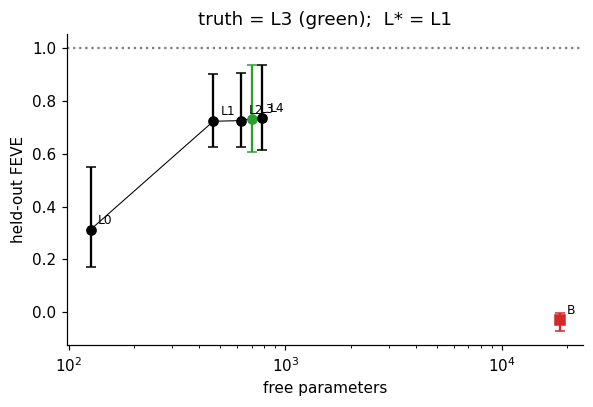

In [5]:
def plot_curve(r, ax):
    for L in LEVELS:
        lo, hi = np.percentile(r["boots"][L], [2.5, 97.5]); x = r["dl"][L][0]
        ax.errorbar(x, r["point"][L], yerr=[[r["point"][L] - lo], [hi - r["point"][L]]], fmt="s" if L == "B" else "o",
                    color="tab:red" if L == "B" else ("tab:green" if L == r["truth"] else "k"), capsize=3)
        ax.annotate(L, (x, r["point"][L]), xytext=(5, 4), textcoords="offset points", fontsize=8)
    w = [L for L in LEVELS if L != "B"]
    ax.plot([r["dl"][L][0] for L in w], [r["point"][L] for L in w], "k-", lw=0.7)
    ax.axhline(1, ls=":", c="0.5"); ax.set_xscale("log"); ax.set_xlabel("free parameters"); ax.set_ylabel("held-out FEVE")
    ax.set_title(f"truth = {r['truth']} (green);  L* = {r['dec']['L_star']}")
fig, ax = plt.subplots(figsize=(5.5, 3.8)); plot_curve(r, ax); plt.tight_layout(); plt.show()

## 2 · Recovery matrix

Each row is a truth, each column a rung, and cells show held-out FEVE. The registered rule should pick the true rung: **a diagonal of recovered L\***. Off-diagonal recoveries are the pipeline's known failure modes, and they must be reported alongside any real-data result.

For publication, repeat over several seeds per truth (`SEEDS`) to estimate the recovery *rate*.

truth L1 seed 1: L* = L1  oracle 1.00  (13.1 min)
truth L2 seed 1: L* = L1  oracle 1.00  (13.4 min)
truth L3 seed 1: L* = L1  oracle 1.00  (13.5 min)
truth L4 seed 1: L* = L3  oracle 1.00  (13.4 min)


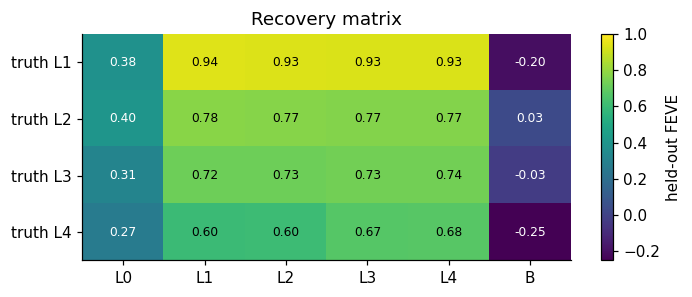

recovered L*: {'L1': ['L1'], 'L2': ['L1'], 'L3': ['L1'], 'L4': ['L3']}


In [6]:
results = {}
for t in TRUTHS:
    for s in SEEDS:
        results[(t, s)] = r if (t == "L3" and s == 1) else run_truth(t, seed=s)
        rr = results[(t, s)]; print(f"truth {t} seed {s}: L* = {rr['dec']['L_star']}  oracle {rr['oracle']:.2f}  ({rr['minutes']:.1f} min)")
mat = np.array([[np.mean([results[(t, s)]["point"][L] for s in SEEDS]) for L in LEVELS] for t in TRUTHS])
fig, ax = plt.subplots(figsize=(6.5, 0.6 + 0.55 * len(TRUTHS)))
im = ax.imshow(mat, cmap="viridis", vmin=min(0, mat.min()), vmax=1, aspect="auto")
for i in range(len(TRUTHS)):
    for j in range(len(LEVELS)):
        ax.text(j, i, f"{mat[i, j]:.2f}", ha="center", va="center", color="w" if mat[i, j] < 0.6 else "k", fontsize=8)
ax.set_xticks(range(len(LEVELS))); ax.set_xticklabels(LEVELS); ax.set_yticks(range(len(TRUTHS))); ax.set_yticklabels([f"truth {t}" for t in TRUTHS])
plt.colorbar(im, ax=ax, label="held-out FEVE"); ax.set_title("Recovery matrix"); plt.tight_layout(); plt.show()
recov = {t: [results[(t, s)]["dec"]["L_star"] for s in SEEDS] for t in TRUTHS}
print("recovered L*:", recov)

## 3 · Power: when can L3 be told apart from L2?

The real-data unc-31 estimate (Notebook 03) has a CI reaching zero, so power for the L2-vs-L3 decision is the key planning number. With truth = L3, we vary the peptide strength and the number of trials, and record how often the pipeline correctly places L* at L3 or above (i.e. detects that the peptide channel is needed).

This grid is the slowest part of the notebook. Results are checkpointed, so you can stop and resume.

peptide scale 0.5, trials x1: detection rate 0.00
peptide scale 0.5, trials x4: detection rate 0.00
peptide scale 1.0, trials x1: detection rate 1.00
peptide scale 1.0, trials x4: detection rate 1.00


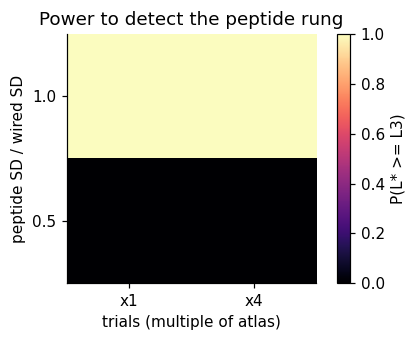

In [7]:
order = {L: i for i, L in enumerate(["L0", "L1", "L2", "L3", "L4"])}
power = np.full((len(PEP_GRID), len(TRIAL_GRID)), np.nan)
for a, ps in enumerate(PEP_GRID):
    for b, tm in enumerate(TRIAL_GRID):
        hits = []
        for s in SEEDS:
            rr = run_truth("L3", seed=s, peptide_scale=ps, trials_mult=tm)
            Ls = rr["dec"]["L_star"]
            hits.append(Ls is not None and order[Ls] >= order["L3"])
        power[a, b] = np.mean(hits)
        print(f"peptide scale {ps}, trials x{tm}: detection rate {power[a, b]:.2f}")
if power.size > 1:
    fig, ax = plt.subplots(figsize=(4.5, 3.2))
    im = ax.imshow(power, vmin=0, vmax=1, cmap="magma", origin="lower")
    ax.set_xticks(range(len(TRIAL_GRID))); ax.set_xticklabels([f"x{t}" for t in TRIAL_GRID]); ax.set_xlabel("trials (multiple of atlas)")
    ax.set_yticks(range(len(PEP_GRID))); ax.set_yticklabels(PEP_GRID); ax.set_ylabel("peptide SD / wired SD")
    plt.colorbar(im, label="P(L* >= L3)"); ax.set_title("Power to detect the peptide rung"); plt.tight_layout(); plt.show()

## 4 · Protocol check: held-out stimulated neurons

The stricter protocol from the proposal holds out entire stimulated neurons. We run it once (truth = L3) to quantify how much harder it is. This is the number to cite when explaining why pair holdout is the primary protocol.

In [8]:
r_stim = run_truth("L3", protocol="stimuli")
print(M.format_decision(r_stim["dec"]))
print("\nFEVE, pairs vs whole-stimulus holdout:")
for L in LEVELS:
    print(f"  {L}: {results[('L3', SEEDS[0])]['point'][L]:+.3f}  vs  {r_stim['point'][L]:+.3f}")

rung   FEVE(held-out)   max upper-CI gain of any deeper rung
L0        0.007         +0.958
L1        0.549         +0.093
L2        0.034         +0.069
L3       -1.456         +0.032
L4       -1.449            —
=> closed level L* = None   (no rung qualifies)

FEVE, pairs vs whole-stimulus holdout:
  L0: +0.313  vs  +0.007
  L1: +0.724  vs  +0.549
  L2: +0.726  vs  +0.034
  L3: +0.733  vs  -1.456
  L4: +0.735  vs  -1.449
  B: -0.031  vs  -0.040


In [9]:
out = {"template": template.meta, "config": dict(K=K, STEPS=STEPS, PEPTIDE_SCALE=PEPTIDE_SCALE, N_NEURONS=N_NEURONS, SEEDS=SEEDS),
       "recovery": recov, "recovery_feve": {t: dict(zip(LEVELS, map(float, row))) for t, row in zip(TRUTHS, mat)},
       "power": {"peptide_scale": PEP_GRID, "trials_mult": TRIAL_GRID, "rate": power.tolist()},
       "stimulus_holdout_feve": {L: float(v) for L, v in r_stim["point"].items()}}
json.dump(out, open(os.path.join(RESULTS, f"synthetic_validation_{MODE}.json"), "w"), indent=2, default=str)
print(json.dumps({k: out[k] for k in ["recovery", "power"]}, indent=1))

{
 "recovery": {
  "L1": [
   "L1"
  ],
  "L2": [
   "L1"
  ],
  "L3": [
   "L1"
  ],
  "L4": [
   "L3"
  ]
 },
 "power": {
  "peptide_scale": [
   0.5,
   1.0
  ],
  "trials_mult": [
   1,
   4
  ],
  "rate": [
   [
    0.0,
    0.0
   ],
   [
    1.0,
    1.0
   ]
  ]
 }
}


## 5 · Go / no-go for Notebook 04

Proceed to real data only if (a) the oracle scores ≈1, (b) the recovery matrix is close to diagonal for the truths you care about, and (c) power at the atlas's actual trial counts and the estimated peptide strength is adequate. If (c) fails, report it as a design constraint: E1 on current data can test L0–L2 closure but cannot adjudicate L3. Point to the data that would (e.g. more unc-31 trials, or time-course rather than amplitude targets).